# Thermal Model Analysis:Physics,ML Surrogates and Sensitivity

Import Libraries

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

Physics Model Definition (Heat Sink)

In [79]:
"""
Property of Expert Thermal/XThermal
"""
import numpy as np

L_die = 0.0525 #Die length in m
W_die = 0.045 #Die Width in m
Thickness_die = 0.0022 #die Thickness in m


TDP = 150  # Thermal Design Power in Watts
T_ambient = 25  # Ambient temperature in Celsius
L = 90e-3  # Heat sink length in meters
W = 116e-3  # Heat sink width in meters
H = 27e-3  # Heat sink height in meters
Fin_Thickness = 0.8e-3  # Fin thickness in meters
N_fins = 60  # Number of fins
Base_Thickness = 2.5e-3  # Base thickness in meters
V_air = 1  # Air velocity in m/s
k_tim = 4.0  # Thermal conductivity of thermal interface material (TIM) in W/m.K
t_tim = 0.1e-3  # TIM thickness in meters
R_jc = 0.2  # Junction-to-case thermal resistance in °C/W

def heat_sink_design(TDP, V_air, k_tim):

    # Given constants for air at 25 degree C
    k_air = 0.0262  # Thermal conductivity of air (W/m.K)
    nu_air = 1.57e-5  # Kinematic viscosity of air (m²/s)
    Pr_air = 0.71  # Prandtl number

    # Fin Spacing Calculation
    s_f = (W - (N_fins * Fin_Thickness)) / (N_fins - 1)

    # Reynolds Number Calculation
    Re = (V_air * s_f) / nu_air

    # Nusselt Number Calculation (Laminar & Turbulent cases)
    if Re < 2300:  # Laminar flow assumption
        Nu = 1.86 * ((Re * Pr_air * (2 * s_f) / L) ** (1/3))
    else:  # Turbulent flow
        Nu = 0.023 * (Re**0.8) * (Pr_air**0.3)

    # Convective Heat Transfer Coefficient
    h = (Nu * k_air) / (2 * s_f)

    #fin Height

    h_fin = H-Base_Thickness

    # Effective Surface Area Calculation
    A_fin = N_fins * (2 * h_fin * L)+ (s_f * L)
    A_Total_base = (L * W)

    A_base_convection = A_Total_base-(Fin_Thickness*N_fins*L) #only this area is exposed for convectionn

    A_total = A_fin + A_base_convection

    # Convective Thermal Resistance
    R_conv = 1 / (h * A_total)

    # TIM Thermal Resistance
    A_die = L_die*W_die # die area where thermal insulation is done
    R_tim = t_tim / (k_tim * A_die)

    # Total Heat Sink Thermal Resistance
    R_hs = R_conv + R_tim

    # Total Thermal Resistance
    R_total = R_jc + R_hs

    # Junction Temperature Calculation
    T_j = T_ambient + (TDP * R_total)

    print("The Reynolds Number is: ", Re)
    print("The Nusselt Number is: ", Nu)
    print("The Convective Heat Transfer Coefficient (W/m².K) is: ", h)
    print("Total Thermal Resistance (°C/W): ", R_total)
    print("Predicted Processor Junction Temperature (°C): ", T_j)

    return R_total, T_j

R_val,T_val=heat_sink_design(180,7.0,8.0)
print(f"Validation :R_total={R_val:.6f},T_j={T_val:.5f} °C")
print("Target:R_total=0.373043,T_j=80.95652 °C\n")

The Reynolds Number is:  513.8723955521971
The Nusselt Number is:  3.917710005747007
The Convective Heat Transfer Coefficient (W/m².K) is:  44.529383285909724
Total Thermal Resistance (°C/W):  0.2882124015512796
Predicted Processor Junction Temperature (°C):  76.87823227923033
Validation :R_total=0.288212,T_j=76.87823 °C
Target:R_total=0.373043,T_j=80.95652 °C



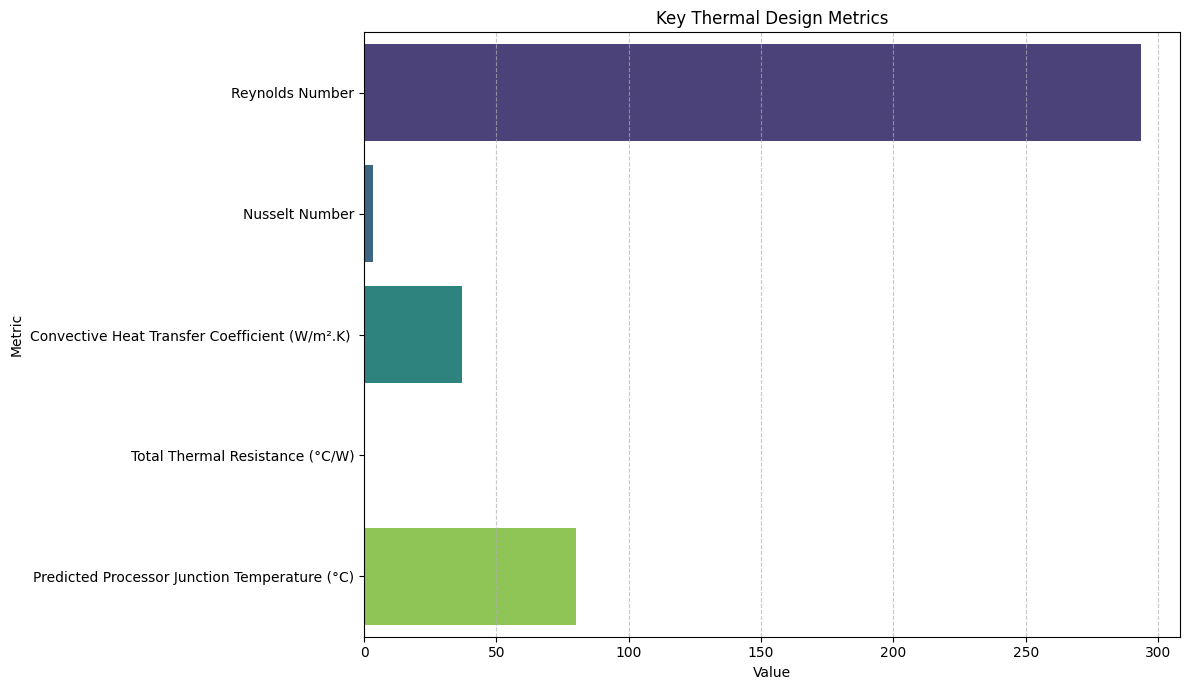

In [80]:
#create a dataFrame for plotting
Metrics={
  "Reynolds Number":  293.64136888696976,
"Nusselt Number":  3.251019712803284,
"Convective Heat Transfer Coefficient (W/m².K) ":  36.951663765083204,
"Total Thermal Resistance (°C/W)":  0.30597304405537484,
"Predicted Processor Junction Temperature (°C)":  80.07514792996747
}
plot_df=pd.DataFrame(list(Metrics.items()) ,columns=['Metrics','Value'])

plt.figure(figsize=(12,7))
sns.barplot(x='Value',y='Metrics', data=plot_df ,palette='viridis',hue='Metrics',legend=False)
plt.title('Key Thermal Design Metrics')
plt.xlabel('Value')
plt.ylabel('Metric')
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

Parameter Sweep and Dataset Generation

In [81]:
print("Generating dataset")
data=[]
for tdp in np.linspace(30,250,22):
  for vel in np.linspace(0.5,15,15):
    for k_tim_val in np.linspace(1,12,12):
        R_th,T_j=heat_sink_design(tdp,vel,k_tim_val)
        data.append([tdp,vel,k_tim_val,R_th,T_j])

df=pd.DataFrame(data,columns=['TDP_W','AirVel_ms','k_TIM','R_th','T_junction'])
df.to_csv('thermal_dataset.csv',index=False)
print(f"saved dataset Thermal.csv with {len(df)} rows\n")

Streaming output truncated to the last 5000 lines.
The Convective Heat Transfer Coefficient (W/m².K) is:  43.915106435224374
Total Thermal Resistance (°C/W):  0.2887844021051522
Predicted Processor Junction Temperature (°C):  82.06929851125628
The Reynolds Number is:  492.89801206027073
The Nusselt Number is:  3.863665723373344
The Convective Heat Transfer Coefficient (W/m².K) is:  43.915106435224374
Total Thermal Resistance (°C/W):  0.2883140905237295
Predicted Processor Junction Temperature (°C):  81.97635598445132
The Reynolds Number is:  492.89801206027073
The Nusselt Number is:  3.863665723373344
The Convective Heat Transfer Coefficient (W/m².K) is:  43.915106435224374
Total Thermal Resistance (°C/W):  0.28792929013892915
Predicted Processor Junction Temperature (°C):  81.90031209888362
The Reynolds Number is:  492.89801206027073
The Nusselt Number is:  3.863665723373344
The Convective Heat Transfer Coefficient (W/m².K) is:  43.915106435224374
Total Thermal Resistance (°C/W):  0.2

Top 10 rows

In [82]:
df.head(10)

,TDP_W,AirVel_ms,k_TIM,R_th,T_junction
0,30.0,0.5,1.0,0.442180,38.265412
1,30.0,0.5,2.0,0.421016,37.630491
2,30.0,0.5,3.0,0.413962,37.418851
3,30.0,0.5,4.0,0.410434,37.313031
4,30.0,0.5,5.0,0.408318,37.249539
5,30.0,0.5,6.0,0.406907,37.207211
6,30.0,0.5,7.0,0.405899,37.176977
7,30.0,0.5,8.0,0.405143,37.154301
8,30.0,0.5,9.0,0.404555,37.136664
9,30.0,0.5,10.0,0.404085,37.122555


Number of rows and columns

In [83]:
df.shape

(3960, 5)

Data Exploration

In [84]:
#check for and remove duplicates rows
initial_rows=len(df)
df.drop_duplicates(inplace=True)
removed_rows=initial_rows-len(df)

if removed_rows>0:
   print(f"Removed {removed_rows} duplicate rows")
else:
   print("No duplicates rows found")
print(f"Dataset now has {len(df)} rows")

No duplicates rows found
Dataset now has 3960 rows


Display DataFrame information

In [85]:
print("\nDataFrame Info")
df.info()


DataFrame Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TDP_W       3960 non-null   float64
 1   AirVel_ms   3960 non-null   float64
 2   k_TIM       3960 non-null   float64
 3   R_th        3960 non-null   float64
 4   T_junction  3960 non-null   float64
dtypes: float64(5)
memory usage: 154.8 KB


Display descriptive statistics

In [86]:
print("\n Descriptive Statistics:")
display(df.describe())


 Descriptive Statistics:


,TDP_W,AirVel_ms,k_TIM,R_th,T_junction
count,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000
mean,140.000000,7.750000,6.500000,0.303921,67.548960
std,66.472371,4.475362,3.452488,0.036364,20.973645
min,30.000000,0.500000,1.000000,0.267846,33.035373
25%,82.380952,3.607143,3.750000,0.278624,49.889654
50%,140.000000,7.750000,6.500000,0.291787,67.053026
75%,197.619048,11.892857,9.250000,0.316285,84.364160
max,250.000000,15.000000,12.000000,0.442180,135.545101


Pair plot of all Variables

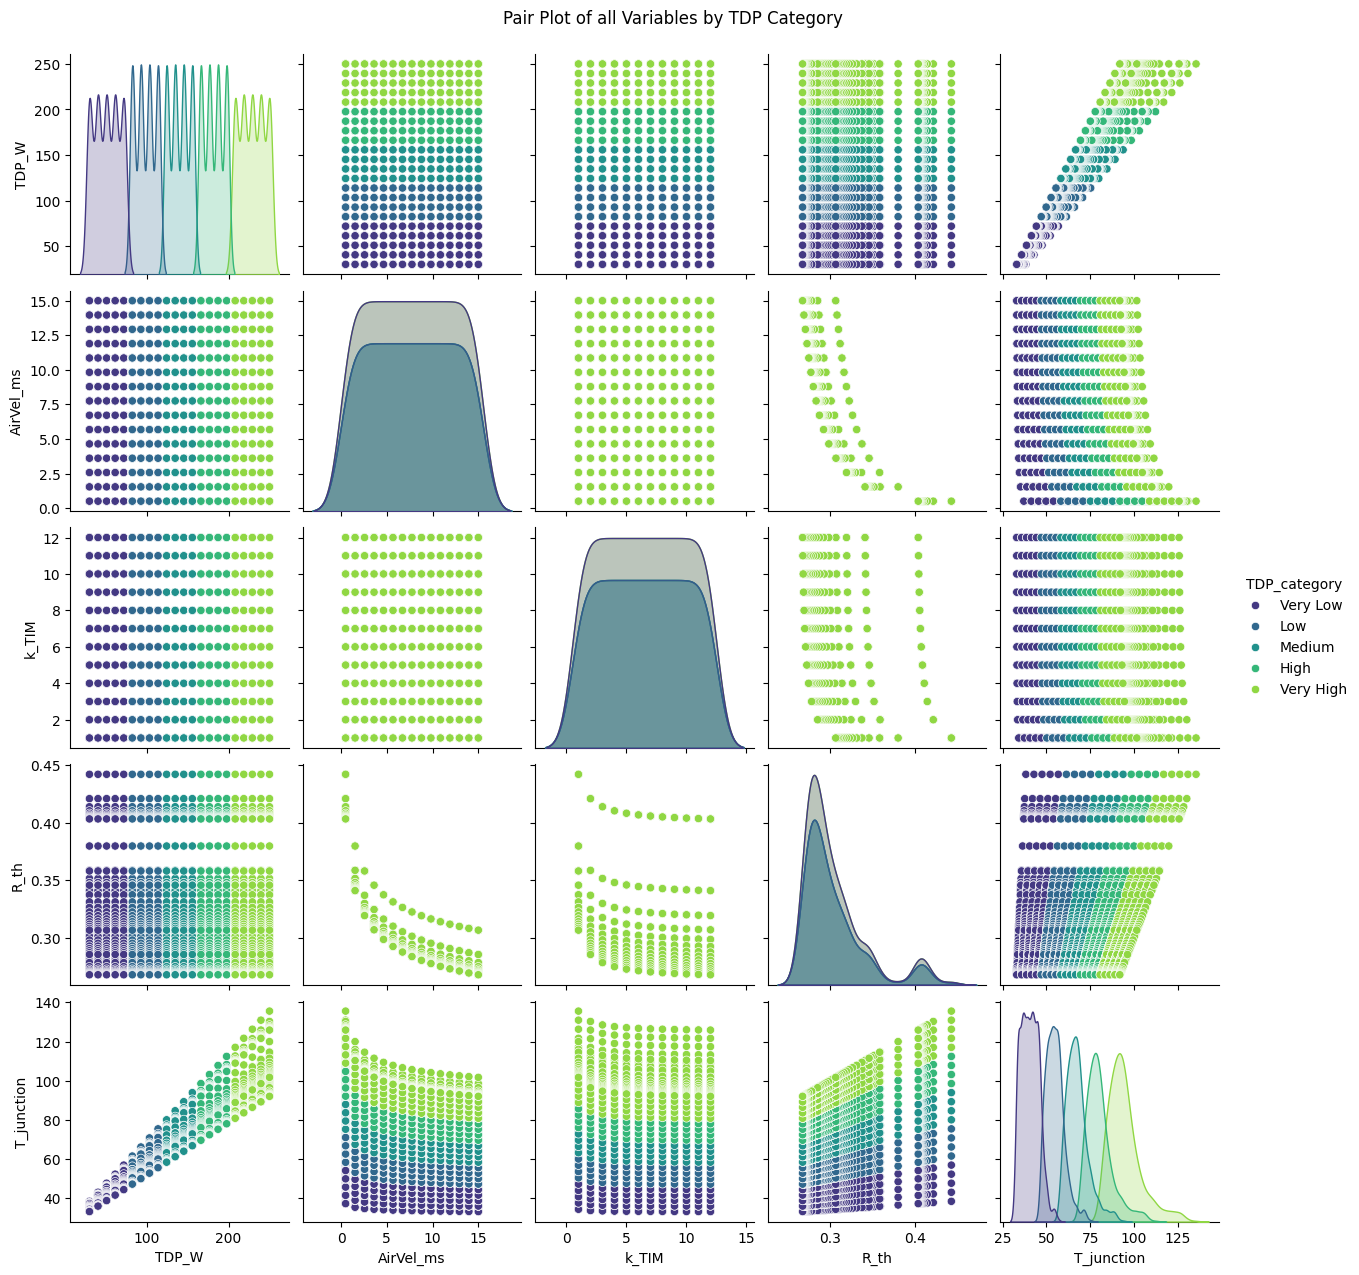

In [87]:
# create bins for TDP_W to categorize it for coloring
tdp_bins=pd.cut(df['TDP_W'],bins=5,labels=['Very Low','Low','Medium','High','Very High'])
df_colored=df.copy()
df_colored['TDP_category']=tdp_bins
sns.pairplot(df_colored,hue='TDP_category',palette='viridis')
plt.suptitle('Pair Plot of all Variables by TDP Category',y=1.02)
plt.show()

ML Surrogate Models:Training and Evaluation

In [88]:
X=df[['TDP_W','AirVel_ms','k_TIM']]
y=df[['R_th','T_junction']]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
models={
    'RandomForest':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1),
    'NeuralNet_MLP':MLPRegressor(hidden_layer_sizes=(64,32),max_iter=5000,random_state=42)
}
results=[]
print("Task 1c:Taining and evaluating ML models")
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)

    mae=mean_absolute_error(y_test,pred)
    rmse=np.sqrt(mean_squared_error(y_test,pred))
    r2=r2_score(y_test,pred)

    results.append([name,mae,rmse,r2])
    joblib.dump(model,f'{name}_thermal_surrogate.pkl')
    print(f"{name:15} | MAE: {mae:.5f} | RMSE: {rmse:.5f} | R²: {r2:.6f}")

results_df=pd.DataFrame(results,columns=['Model','MAE','RMSE','R²'])
results_df.to_csv('Model_comparison.csv',index=False)

Task 1c:Taining and evaluating ML models
RandomForest    | MAE: 0.09018 | RMSE: 0.28400 | R²: 0.994962
NeuralNet_MLP   | MAE: 0.35848 | RMSE: 0.62736 | R²: -1.780435


Model Performance Comaprison:Bar plots

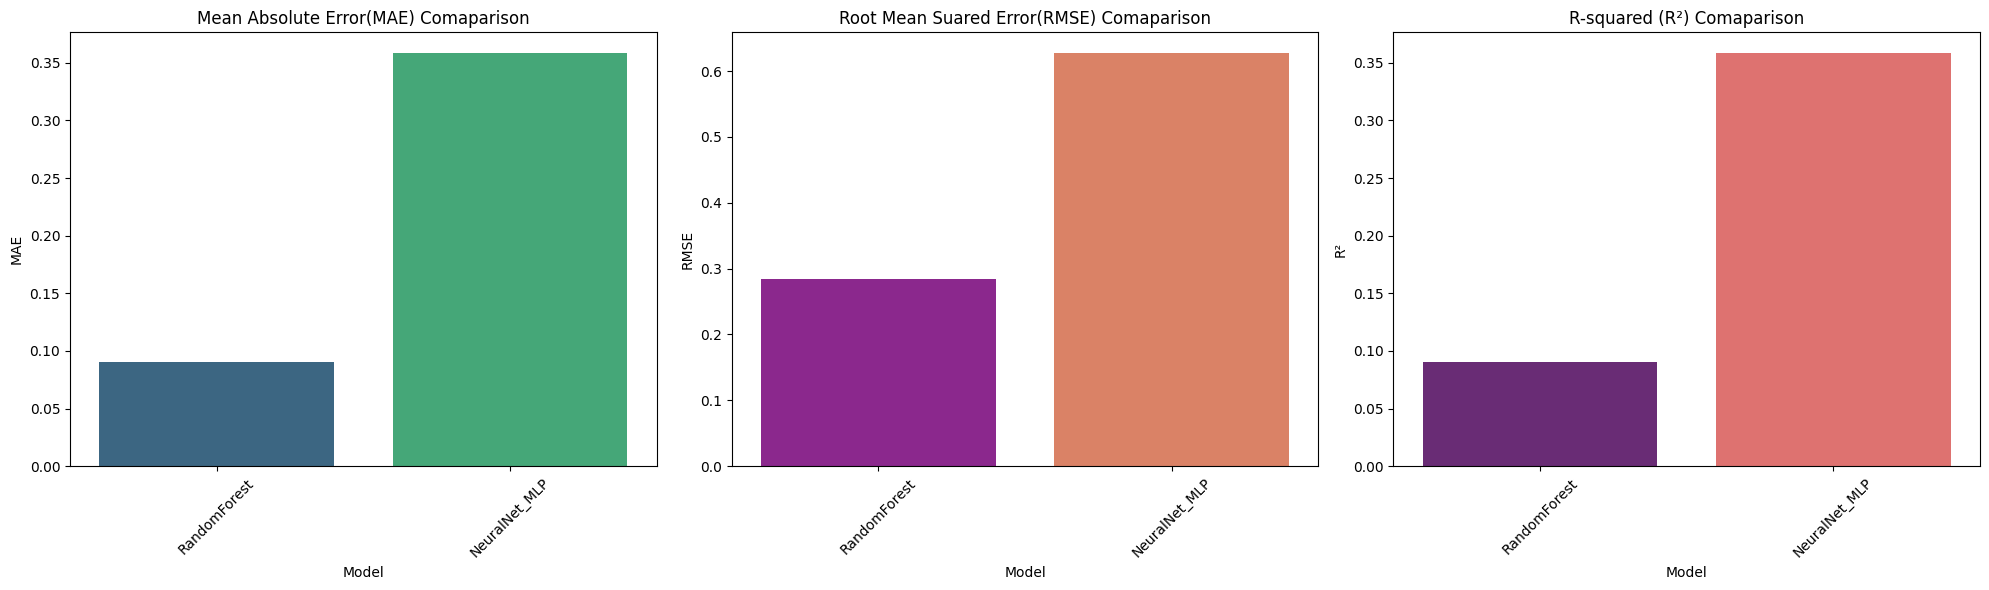

In [89]:
fig, axes=plt.subplots(1,3,figsize=(20,6))
#MAE comparison
sns.barplot(x='Model',y='MAE',data=results_df,ax=axes[0],palette='viridis',hue='Model',legend=False)
axes[0].set_title('Mean Absolute Error(MAE) Comaparison')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x',rotation=45)

#RMSE comaprison
sns.barplot(x='Model',y='RMSE',data=results_df,ax=axes[1],palette='plasma',hue='Model',legend=False)
axes[1].set_title('Root Mean Suared Error(RMSE) Comaparison')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x',rotation=45)

#R² comparison
sns.barplot(x='Model',y='MAE',data=results_df,ax=axes[2],palette='magma',hue='Model',legend=False)
axes[2].set_title('R-squared (R²) Comaparison')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x',rotation=45)

plt.tight_layout()
plt.show()

Model Performance Visualization:Actual vs Predicted Tjunction (RandomForest)

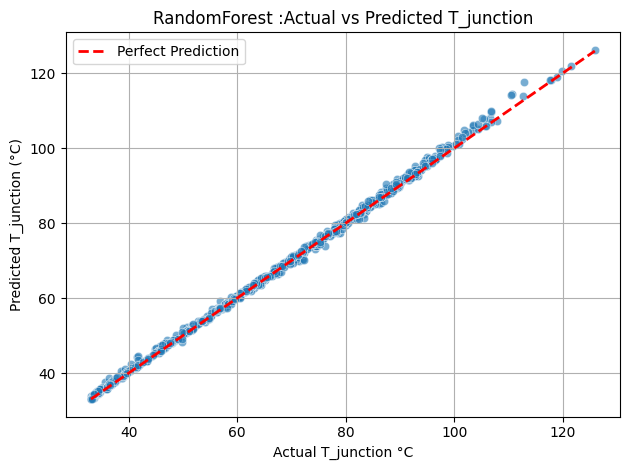

In [90]:
rf_model =models['RandomForest']
y_pred_rf=rf_model.predict(X_test)
actual_T_junction=y_test['T_junction']
predicted_T_junction=pd.Series(y_pred_rf[:,1],index=y_test.index)

sns.scatterplot(x=actual_T_junction,y=predicted_T_junction_mlp,alpha=0.6)
plt.plot([min(actual_T_junction),max(actual_T_junction)] ,[min(actual_T_junction),max(actual_T_junction)],
        color='red',linestyle='--',linewidth=2,label='Perfect Prediction')

plt.title('RandomForest :Actual vs Predicted T_junction')
plt.xlabel('Actual T_junction °C')
plt.ylabel('Predicted T_junction (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Model Performance Visualization:Actual Vs Predicted T_junction (NeuralNet_MLP)

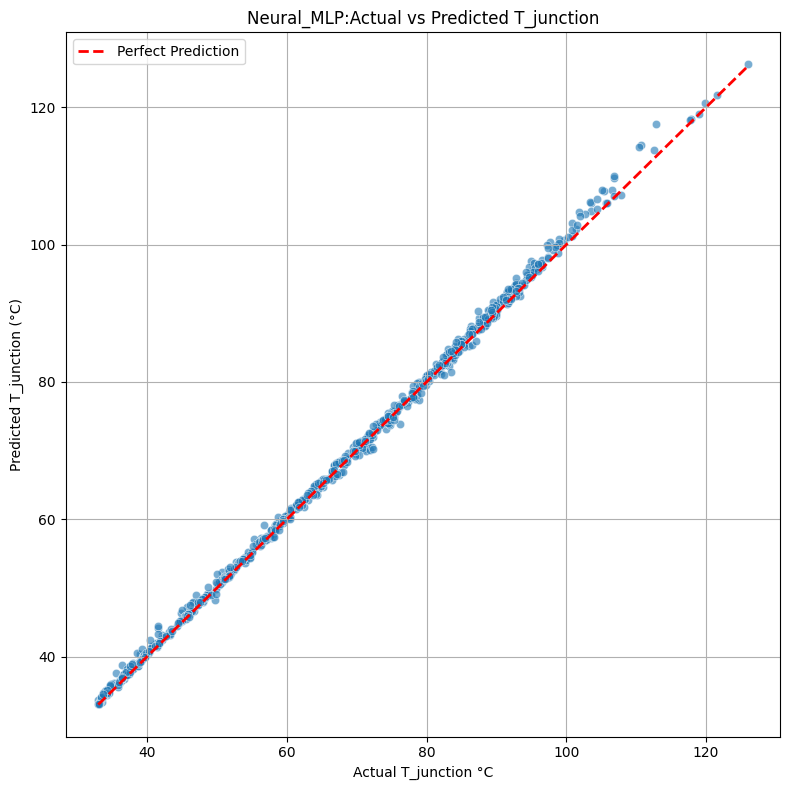

In [91]:
mlp_model=models['NeuralNet_MLP']

y_pred_mlp=mlp_model.predict(X_test)

actual_T_junction=y_test['T_junction']
predicted_T_junction_mlp=pd.Series(y_pred_mlp[:,1],index=y_test.index)

plt.figure(figsize=(8,8))
sns.scatterplot(x=actual_T_junction,y=predicted_T_junction_mlp,alpha=0.6)
plt.plot([min(actual_T_junction),max(actual_T_junction)] ,[min(actual_T_junction),max(actual_T_junction)],
        color='red',linestyle='--',linewidth=2,label='Perfect Prediction')

plt.title('Neural_MLP:Actual vs Predicted T_junction')
plt.xlabel('Actual T_junction °C')
plt.ylabel('Predicted T_junction (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Residual Plots

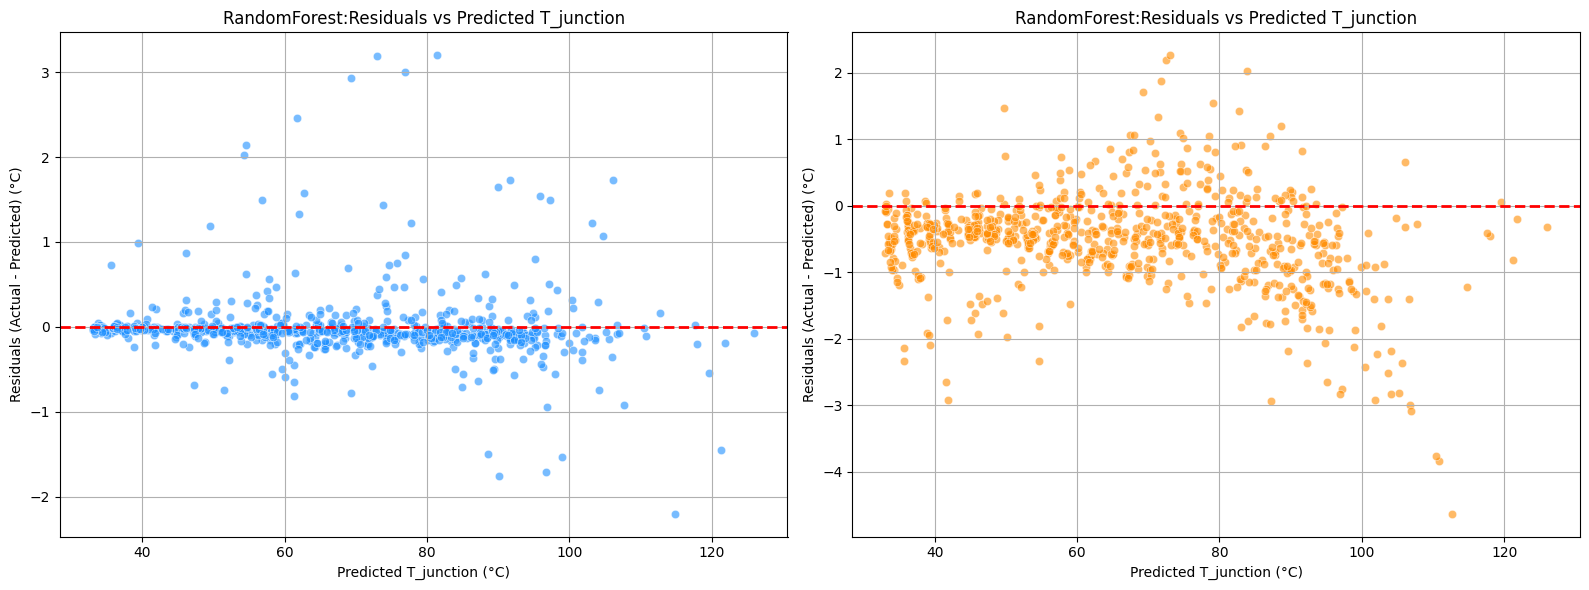

In [92]:
residuals_rf=actual_T_junction - predicted_T_junction
residual_mlp=actual_T_junction-predicted_T_junction_mlp
fig,axes=plt.subplots(1,2,figsize=(16,6))

#RandomForest Residual Plot
sns.scatterplot(x=predicted_T_junction,y=residuals_rf,ax=axes[0],alpha=0.6,color='dodgerblue')
axes[0].axhline(y=0,color='red',linestyle='--',linewidth=2)
axes[0].set_title('RandomForest:Residuals vs Predicted T_junction')
axes[0].set_xlabel('Predicted T_junction (°C)')
axes[0].set_ylabel('Residuals (Actual - Predicted) (°C)')
axes[0].grid(True)

#NeuralNet_MLP Residual Plot
sns.scatterplot(x=predicted_T_junction,y=residual_mlp,ax=axes[1],alpha=0.6,color='darkorange')
axes[1].axhline(y=0,color='red',linestyle='--',linewidth=2)
axes[1].set_title('RandomForest:Residuals vs Predicted T_junction')
axes[1].set_xlabel('Predicted T_junction (°C)')
axes[1].set_ylabel('Residuals (Actual - Predicted) (°C)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Sensitivity Analysis

Task 1d :Sensitivity Analysis
Correlation with T_junction:
T_junction    1.000000
TDP_W         0.963226
R_th          0.242728
k_TIM        -0.055737
AirVel_ms    -0.191848
Name: T_junction, dtype: float64
TDP_W:0.926
AirVel_ms:0.068
k_TIM:0.006
Saved sensitivity_analysis


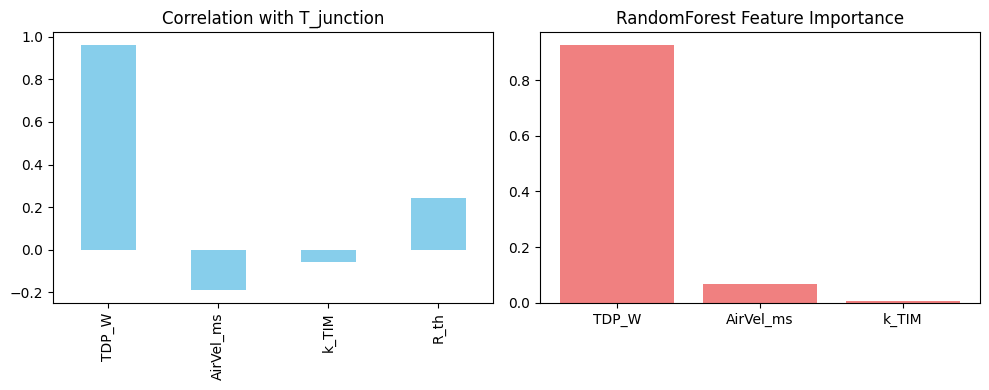

In [93]:
print("Task 1d :Sensitivity Analysis")
#1.correlation matrix
corr=df.corr()
print("Correlation with T_junction:")
print(corr['T_junction'].sort_values(ascending=False))

#2.Feature importamce from RF
rf=models['RandomForest']
importances=rf.feature_importances_
for i, col in enumerate(X.columns):
  print(f"{col}:{importances[i]:.3f}")

#3. Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
corr['T_junction'][:-1].plot(kind='bar',title='Correlation with T_junction',color='skyblue')
plt.subplot(1,2,2)
plt.bar(X.columns,importances,color='lightcoral')
plt.title('RandomForest Feature Importance')
plt.tight_layout()
plt.savefig('sensitivity_analysis.png',dpi=150)
print("Saved sensitivity_analysis")

Dataset Variable distributions

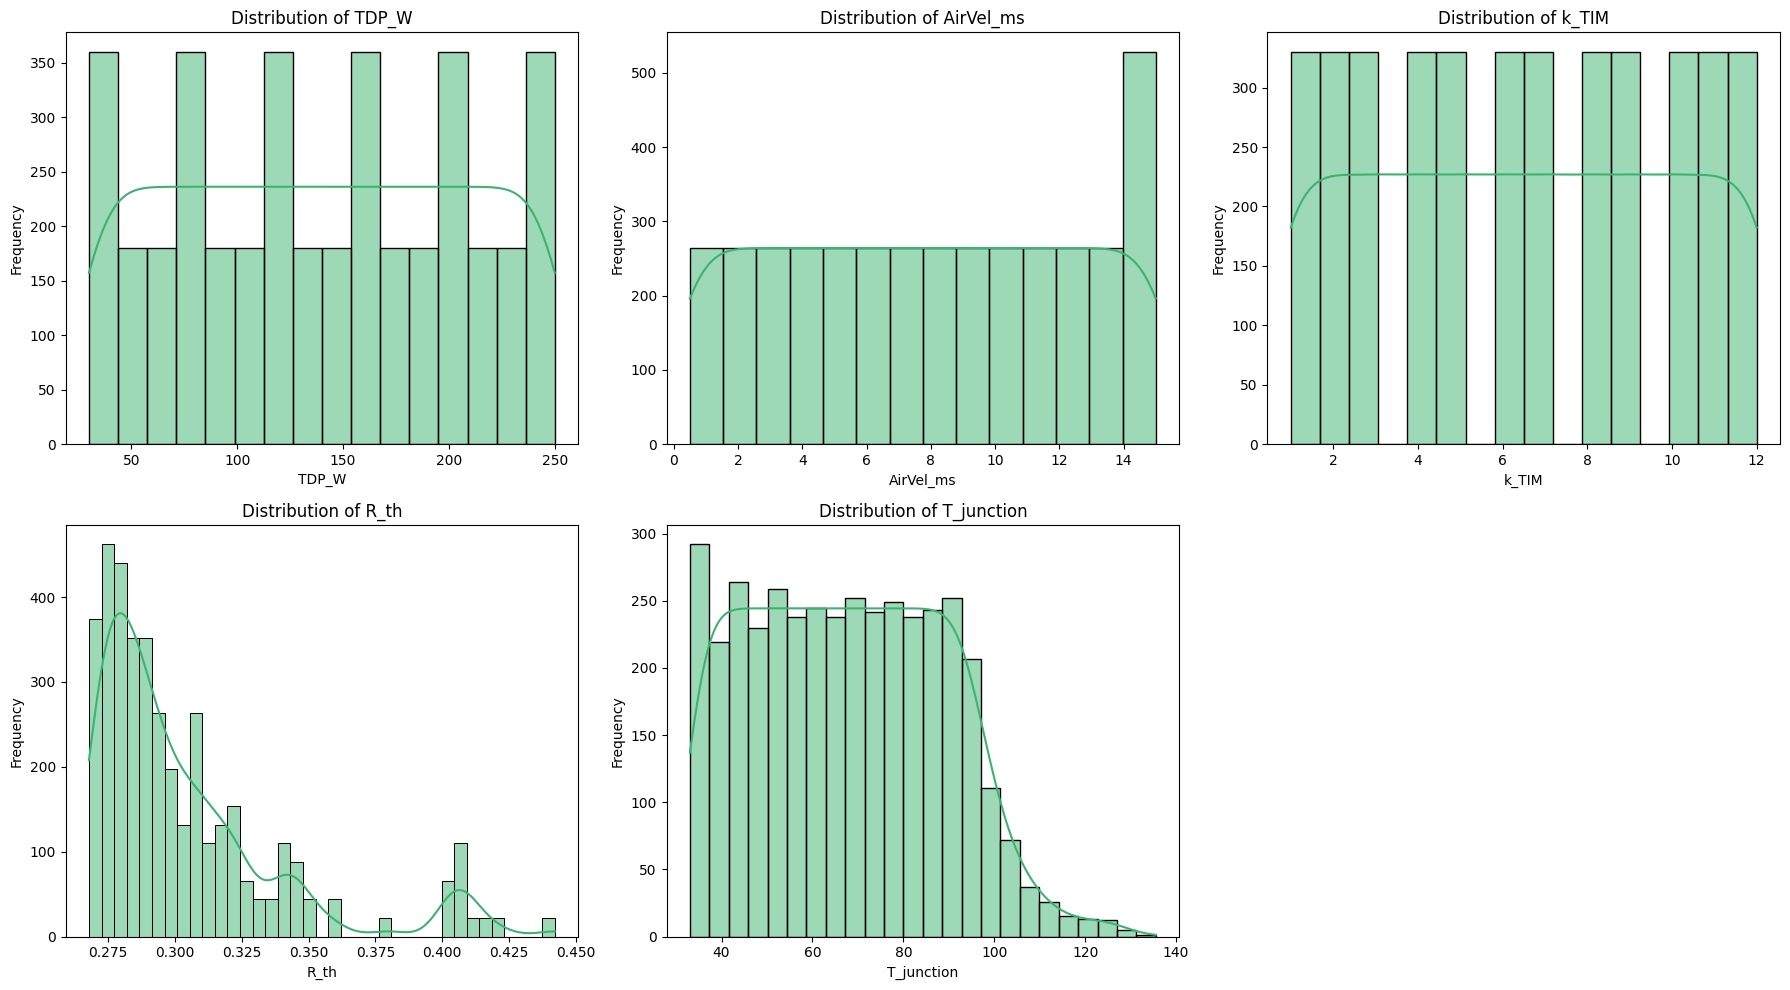

In [94]:
# create a figure with subplots for each variable
fig, axes=plt.subplots(2,3, figsize=(18,10))
axes=axes.flatten()
variables_to_plot=['TDP_W','AirVel_ms','k_TIM','R_th','T_junction']
for i,col in enumerate(variables_to_plot):
    sns.histplot(df[col],kde=True,ax=axes[i],color='mediumseagreen')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

if len(variables_to_plot)<len(axes):
   for j in range(len(variables_to_plot),len(axes)):
       fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Correlation Heatmap of Variables

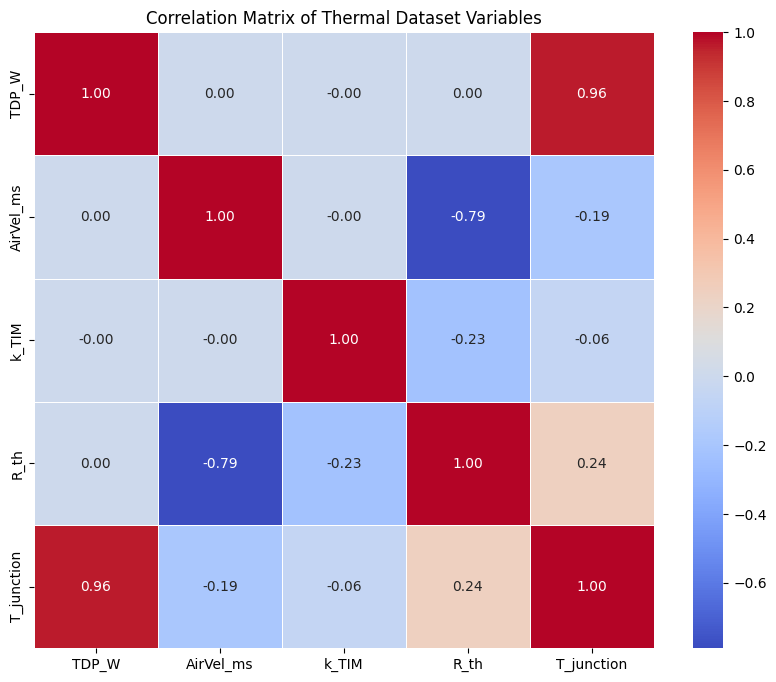

In [95]:
correlation_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=.5)
plt.title('Correlation Matrix of Thermal Dataset Variables')
plt.show()